# Ligand–receptor interaction analysis (post-processing)

## Purpose
This notebook **does not run ligand–receptor (LR) inference**. It post-processes LR inference outputs that were generated externally (typically on HPC due to runtime/memory demands) and produces:
1) a **merged LR interaction table** export
2) a **global ranking** of LR pairs across all conditions
3) a **per-condition top-50** LR pair table

## Inputs
You must provide one of the following:
- **Preferred:** a merged CSV at `interactions_csv_path` (default shown below), or
- an in-memory `pandas.DataFrame` named `df_interactions`

Minimum required columns in `df_interactions`:
- `lr_pair` (or a compatible column like `lr` / `ligand_receptor`; the notebook standardizes names)
- `lr_score_adjust` (or derivable from `lr_score` + `n_spots`, or `n_spots_sig` + `n_spots`)
- `condition` (required for per-condition top-50 table; `Condition` is auto-renamed)

## Outputs
Written to `output_dir` (edit in the parameters cell):
- `all_lr_interactions_scores.csv` (full standardized interaction table)
- `ligand_receptor_analysis_top50.csv` (top-50 LR pairs per condition)
Optional (recommended): save the global top-500 ranking scatter plot as PDF/PNG.

## Dependencies
- Python: `pandas`, `numpy`, `matplotlib`
(No `scanpy/squidpy/stlearn` required here because inference is not run in this notebook.)

## Recommended run order
Run cells top-to-bottom:
1) Parameters and helper (`standardize_df_interactions`)
2) Load merged interactions (`df_interactions`)
3) Export standardized full table
4) Global ranking (optionally save the plot)
5) Per-condition top-50 table export

## Notes / pitfalls
- This notebook assumes LR inference was done elsewhere and outputs were merged into a single table.
- If your merged table uses different column names, the helper `standardize_df_interactions()` attempts to normalize them.
- The current global ranking plot is not saved by default—consider adding `fig.savefig(...)` for reproducibility.

In [ ]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ---------------------------
# Parameters (edit as needed)
# ---------------------------

# Large input files for this notebook are hosted on Zenodo; download and unpack the Zenodo bundle locally and set the base data path below to your local folder.
DATA_ROOT = "data_external/nguyenlab-il15act-dataset-v1"

# Shared temp directory required by the analysis spec.
output_dir = Path(
    "/data/kanferg/Sptial_Omics/projects/NguyenLab/spatialomicstoolkit/temp"
 )
output_dir.mkdir(parents=True, exist_ok=True)

# If `df_interactions` is not already in memory, the notebook will attempt to load it from here.
# Default points to the merged table already used for downstream exports.
interactions_csv_path = Path(DATA_ROOT) / "03_lr_outputs" / "all_lr_interactions_scores.csv"

# Conditions to report top-50 LR pairs for (per-condition mean lr_score_adjust).
conditions = ["TCR", "IL-15", "IL-21", "Both"]

# Ranks (1-based) to annotate on the global top-500 scatter plot.
interesting = [4, 5]

# Prefer a consistent, publication-friendly default style without hard-coded custom colors.
plt.rcParams.update({"figure.dpi": 120})


def standardize_df_interactions(df: pd.DataFrame) -> pd.DataFrame:
    """Standardize column names and ensure required score columns exist.

    This notebook expects (at minimum):
    - an LR pair identifier column (`lr_pair`)
    - a numeric `lr_score_adjust` column
    - a `condition` column for per-condition summaries

    If `lr_score_adjust` is missing but `n_spots` and `n_spots_sig` are present,
    we compute:
        lr_score = n_spots_sig / n_spots
        lr_score_adjust = lr_score * log(n_spots + 1)
    """
    df = df.copy()

    # LR pair identifier: prefer explicit columns; otherwise fall back to the first unnamed CSV column.
    lr_pair_candidates = [
        "lr_pair",
        "lr",
        "ligand_receptor",
        "ligand_receptor_pair",
        "ligand_receptor_pairs",
        "Unnamed: 0",
    ]
    lr_pair_source = next((c for c in lr_pair_candidates if c in df.columns), None)
    if lr_pair_source is None and {"ligand", "receptor"}.issubset(df.columns):
        df["lr_pair"] = df["ligand"].astype(str) + "_" + df["receptor"].astype(str)
    elif lr_pair_source is not None and lr_pair_source != "lr_pair":
        df = df.rename(columns={lr_pair_source: "lr_pair"})

    # Condition column name normalization.
    if "condition" not in df.columns and "Condition" in df.columns:
        df = df.rename(columns={"Condition": "condition"})

    # Score derivations (only if needed).
    if "lr_score" not in df.columns and {"n_spots", "n_spots_sig"}.issubset(df.columns):
        n_spots = pd.to_numeric(df["n_spots"], errors="coerce")
        n_spots_sig = pd.to_numeric(df["n_spots_sig"], errors="coerce")
        df["lr_score"] = n_spots_sig / n_spots.replace(0, np.nan)

    if "lr_score_adjust" not in df.columns:
        if {"lr_score", "n_spots"}.issubset(df.columns):
            lr_score = pd.to_numeric(df["lr_score"], errors="coerce")
            n_spots = pd.to_numeric(df["n_spots"], errors="coerce")
            df["lr_score_adjust"] = lr_score * np.log(n_spots + 1.0)
        else:
            raise KeyError(
                "Missing `lr_score_adjust` and cannot derive it. "
                "Provide a table with `lr_score_adjust`, or with `lr_score` + `n_spots`, "
                "or with `n_spots` + `n_spots_sig`."
            )

    # Final minimal checks for downstream steps.
    required_cols = {"lr_pair", "lr_score_adjust"}
    missing = required_cols - set(df.columns)
    if missing:
        raise KeyError(f"df_interactions is missing required columns: {sorted(missing)}")

    return df

In [2]:
# ---------------------------
# Load merged LR interactions
# ---------------------------

# IMPORTANT: This cell does NOT run LR inference. It only loads HPC outputs.

if "df_interactions" in globals() and isinstance(df_interactions, pd.DataFrame):
    df_interactions = df_interactions.copy()
elif interactions_csv_path.exists():
    df_interactions = pd.read_csv(interactions_csv_path)
else:
    raise FileNotFoundError(
        "Neither an in-memory `df_interactions` DataFrame was found, "
        f"nor did the expected CSV exist: {interactions_csv_path}\n\n"
        "Provide `df_interactions` in memory, or set `interactions_csv_path` to a valid CSV."
    )

df_interactions = standardize_df_interactions(df_interactions)

print(f"Loaded interactions from: {interactions_csv_path}")
print(f"df_interactions shape: {df_interactions.shape}")
print(f"Columns: {sorted(df_interactions.columns.tolist())}")
df_interactions.head(10)

Loaded interactions from: /data/kanferg/Sptial_Omics/projects/NguyenLab/spatialomicstoolkit/temp/all_lr_interactions_scores.csv
df_interactions shape: (20092, 10)
Columns: ['batch', 'condition', 'lr_pair', 'lr_score', 'lr_score_adjust', 'mouse', 'n_spots', 'n_spots_sig', 'n_spots_sig_pval', 'time']


,lr_pair,batch,condition,time,mouse,n_spots,n_spots_sig,n_spots_sig_pval,lr_score,lr_score_adjust
0,Pltp_Abca1,0,IL-15,8,777,8143.0,1486.0,3276.0,0.182488,1.643311
1,Col1a2_Itgb1,0,IL-15,8,777,7091.0,1383.0,2305.0,0.195036,1.729330
2,Col1a2_Cd44,0,IL-15,8,777,4208.0,1209.0,1887.0,0.287310,2.397595
3,Cd84_Cd84,0,IL-15,8,777,4170.0,1168.0,2293.0,0.280096,2.334855
4,Fn1_Itgb1,0,IL-15,8,777,6971.0,1145.0,2001.0,0.164252,1.453573
5,App_Lrp1,0,IL-15,8,777,8588.0,1084.0,2497.0,0.126223,1.143355
6,Col1a1_Itgb1,0,IL-15,8,777,6815.0,1081.0,1836.0,0.158621,1.400149
7,Col1a2_Cd93,0,IL-15,8,777,3819.0,1074.0,1753.0,0.281225,2.319549
8,Col1a2_Itgb3,0,IL-15,8,777,2848.0,1012.0,1506.0,0.355337,2.826608
9,Grn_Tnfrsf1b,0,IL-15,8,777,8182.0,999.0,2747.0,0.122097,1.100074


In [3]:
# ---------------------------
# Exports (full interactions)
# ---------------------------

full_out_path = output_dir / "all_lr_interactions_scores.csv"
df_interactions.to_csv(full_out_path, index=False)
print(f"Wrote full interaction table: {full_out_path}")

Wrote full interaction table: /data/kanferg/Sptial_Omics/projects/NguyenLab/spatialomicstoolkit/temp/all_lr_interactions_scores.csv


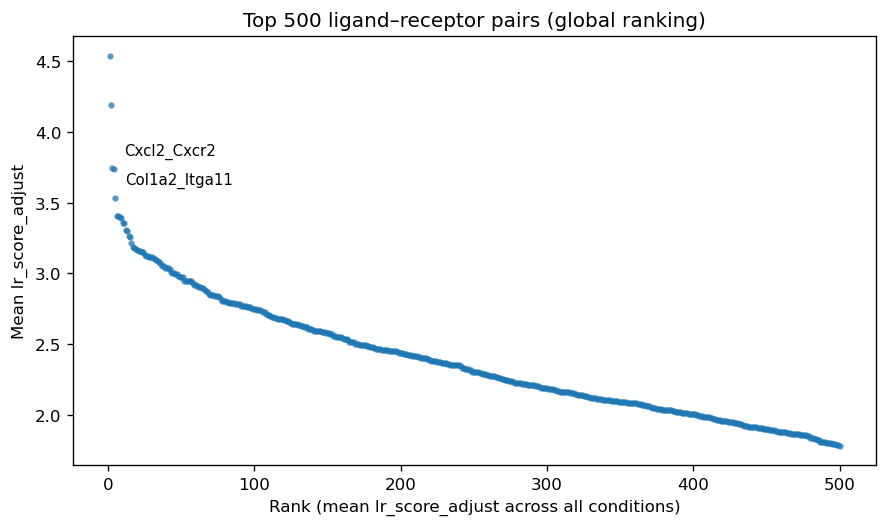

In [4]:
# -------------------------------------------
# Global ranking + ranked scatter (top 500)
# -------------------------------------------

# We aggregate by LR pair using the mean to collapse replicate-level rows into a single score per pair.
df_ranked_all = (
    df_interactions.groupby("lr_pair", as_index=False)["lr_score_adjust"]
    .mean()
    .rename(columns={"lr_score_adjust": "mean_lr_score_adjust"})
    .sort_values("mean_lr_score_adjust", ascending=False)
    .reset_index(drop=True)
 )

df_top500 = df_ranked_all.head(500).copy()
df_top500["rank"] = np.arange(1, len(df_top500) + 1)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.scatter(
    df_top500["rank"],
    df_top500["mean_lr_score_adjust"],
    s=14,
    alpha=0.75,
    linewidths=0,
 )
ax.set_xlabel("Rank (mean lr_score_adjust across all conditions)")
ax.set_ylabel("Mean lr_score_adjust")
ax.set_title("Top 500 ligand–receptor pairs (global ranking)")

# Annotate selected ranks (1-based). Safely ignore out-of-range indices.
for rank in interesting:
    if not isinstance(rank, int):
        continue
    if 1 <= rank <= len(df_top500):
        row = df_top500.iloc[rank - 1]
        ax.annotate(
            str(row["lr_pair"]),
            xy=(row["rank"], row["mean_lr_score_adjust"]),
            xytext=(6, 6),
            textcoords="offset points",
            fontsize=9,
            ha="left",
            va="bottom",
        )

plt.tight_layout()

In [5]:
# -------------------------------------------------
# Per-condition top-50 LR pairs + export as a table
# -------------------------------------------------

if "condition" not in df_interactions.columns:
    raise KeyError(
        "`df_interactions` must contain a `condition` column for per-condition top-50 tables. "
        "If your source table uses a different column name, rename it before calling this cell."
    )

df_condition_means = (
    df_interactions[df_interactions["condition"].isin(conditions)]
    .groupby(["condition", "lr_pair"], as_index=False)["lr_score_adjust"]
    .mean()
    .rename(columns={"lr_score_adjust": "mean_lr_score_adjust"})
 )

top_tables = []
for condition_select in conditions:
    df_cond = df_condition_means.loc[
        df_condition_means["condition"] == condition_select
    ].sort_values("mean_lr_score_adjust", ascending=False)

    df_cond = df_cond.head(50).copy()
    df_cond["rank_within_condition"] = np.arange(1, len(df_cond) + 1)
    top_tables.append(df_cond)

df_top50 = pd.concat(top_tables, ignore_index=True)

top50_out_path = output_dir / "ligand_receptor_analysis_top50.csv"
df_top50.to_csv(top50_out_path, index=False)
print(f"Wrote per-condition top-50 table: {top50_out_path}")

df_top50.head(10)

Wrote per-condition top-50 table: /data/kanferg/Sptial_Omics/projects/NguyenLab/spatialomicstoolkit/temp/ligand_receptor_analysis_top50.csv


,condition,lr_pair,mean_lr_score_adjust,rank_within_condition
0,TCR,Slamf6_Slamf6,4.489890,1
1,TCR,Cadm3_Cadm3,4.341143,2
2,TCR,Robo2_Robo2,3.811810,3
3,TCR,Rspo1_Lgr6,3.702530,4
4,TCR,Fgf18_Fgfr4,3.559792,5
5,TCR,Col1a2_Itga11,3.529236,6
6,TCR,Wnt3a_Fzd10,3.522103,7
7,TCR,Ceacam1_Sele,3.493918,8
8,TCR,Pthlh_Pth1r,3.482556,9
9,TCR,Ccl11_Ccr3,3.454362,10
